In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix


In [3]:
PREPROCESSED_DIR = "/content/drive/MyDrive/Processed"
MODEL_DIR = "/content/drive/MyDrive/Processed"

In [4]:
files = [f for f in os.listdir(PREPROCESSED_DIR) if f.endswith('.npz')]
files = sorted(files)

X_list = []
y_list = []

for fn in files:
    data = np.load(os.path.join(PREPROCESSED_DIR, fn), allow_pickle=True)
    beats = data['beats']    # shape: (n_beats, beat_length)
    labels = data['labels']  # list of strings
    X_list.append(beats)
    y_list.extend(labels)

X = np.vstack(X_list)   # (num_beats, beat_length)
y = np.array(y_list)
print("X shape:", X.shape, "y shape:", y.shape)


X shape: (97737, 250) y shape: (97737,)


In [5]:
le = LabelEncoder()
y_int = le.fit_transform(y)
classes = list(le.classes_)
num_classes = len(classes)
print("Classes:", classes)

# Stratified train/validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y_int, test_size=0.2, random_state=42, stratify=y_int
)
print("Train:", X_train.shape, "Val:", X_val.shape)


Classes: [np.str_('F'), np.str_('N'), np.str_('S'), np.str_('V')]
Train: (78189, 250) Val: (19548, 250)


In [6]:
# LSTM expects 3D input: (samples, time_steps, features)
X_train_lstm = X_train[..., np.newaxis]  # (num_beats, beat_length, 1)
X_val_lstm = X_val[..., np.newaxis]
input_shape = X_train_lstm.shape[1:]   # (beat_length, 1)


In [7]:
lstm_model = Sequential([
    LSTM(64, input_shape=input_shape, return_sequences=True),
    LSTM(32),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

lstm_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
lstm_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 250, 64)        │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,444 (115.02 KB)

 Trainable params: 29,444 (115.02 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
history = lstm_model.fit(
    X_train_lstm, y_train,
    validation_data=(X_val_lstm, y_val),
    epochs=25,
    batch_size=64,
    verbose=2
)

Epoch 1/25
1222/1222 - 29s - 24ms/step - accuracy: 0.9068 - loss: 0.3857 - val_accuracy: 0.9116 - val_loss: 0.3262
Epoch 2/25
1222/1222 - 24s - 20ms/step - accuracy: 0.9247 - loss: 0.2669 - val_accuracy: 0.9084 - val_loss: 0.3816
Epoch 3/25
1222/1222 - 26s - 21ms/step - accuracy: 0.9202 - loss: 0.2932 - val_accuracy: 0.9522 - val_loss: 0.1997
Epoch 4/25
1222/1222 - 26s - 22ms/step - accuracy: 0.9433 - loss: 0.2088 - val_accuracy: 0.9542 - val_loss: 0.1726
Epoch 5/25
1222/1222 - 23s - 19ms/step - accuracy: 0.9574 - loss: 0.1695 - val_accuracy: 0.9632 - val_loss: 0.1439
Epoch 6/25
1222/1222 - 23s - 19ms/step - accuracy: 0.9634 - loss: 0.1463 - val_accuracy: 0.9667 - val_loss: 0.1308
Epoch 7/25
1222/1222 - 24s - 19ms/step - accuracy: 0.9675 - loss: 0.1315 - val_accuracy: 0.9691 - val_loss: 0.1212
Epoch 8/25
1222/1222 - 24s - 19ms/step - accuracy: 0.9702 - loss: 0.1214 - val_accuracy: 0.9701 - val_loss: 0.1164
Epoch 9/25
1222/1222 - 24s - 19ms/step - accuracy: 0.9687 - loss: 0.1258 - val_a

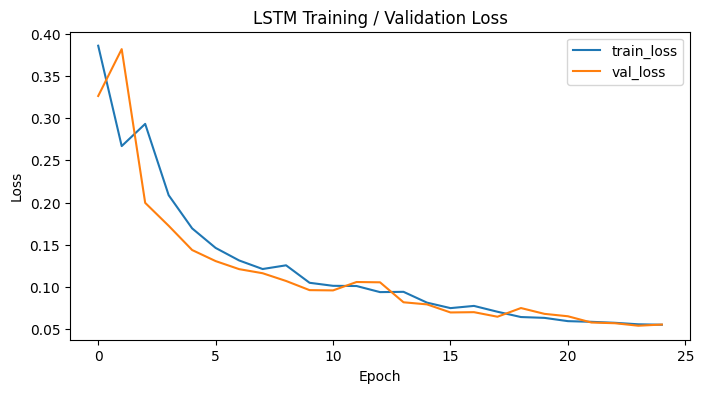

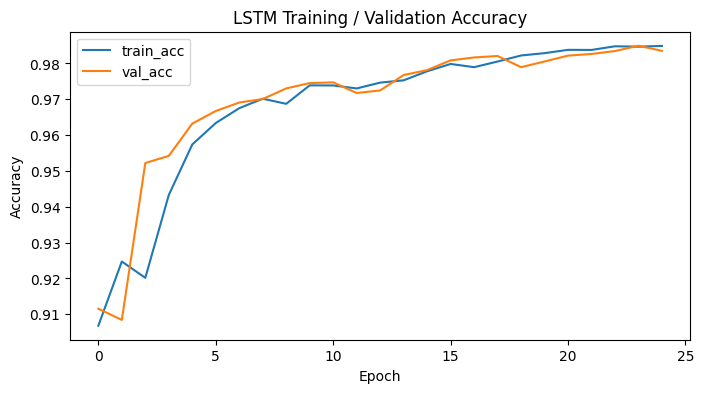

In [9]:
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title("LSTM Training / Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8,4))
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title("LSTM Training / Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


In [10]:
y_pred_val = np.argmax(lstm_model.predict(X_val_lstm), axis=1)

cm = confusion_matrix(y_val, y_pred_val)
print("LSTM Confusion Matrix:\n", cm)

print("\nClassification Report:\n")
print(classification_report(y_val, y_pred_val, target_names=classes))


611/611 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step
LSTM Confusion Matrix:
 [[  102    41     0    15]
 [    5 17661    60    17]
 [    0   110   425     3]
 [   10    58     3  1038]]

Classification Report:

              precision    recall  f1-score   support

           F       0.87      0.65      0.74       158
           N       0.99      1.00      0.99     17743
           S       0.87      0.79      0.83       538
           V       0.97      0.94      0.95      1109

    accuracy                           0.98     19548
   macro avg       0.92      0.84      0.88     19548
weighted avg       0.98      0.98      0.98     19548



## RandomClassidier Model

In [11]:
def extract_features(beats):
    """
    Compute simple statistical features per beat:
    - mean, std, min, max, RMS, energy
    Returns array of shape (num_beats, num_features)
    """
    features = []
    for beat in beats:
        mean = np.mean(beat)
        std = np.std(beat)
        mn = np.min(beat)
        mx = np.max(beat)
        rms = np.sqrt(np.mean(beat**2))
        energy = np.sum(beat**2)
        features.append([mean, std, mn, mx, rms, energy])
    return np.array(features)

# Extract features
X_train_rf = extract_features(X_train)
X_val_rf = extract_features(X_val)
print("RF feature shape:", X_train_rf.shape)


RF feature shape: (78189, 6)


In [12]:
rf_model = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
rf_model.fit(X_train_rf, y_train)


RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [13]:
y_pred_rf = rf_model.predict(X_val_rf)

cm_rf = confusion_matrix(y_val, y_pred_rf)
print("Random Forest Confusion Matrix:\n", cm_rf)

print("\nClassification Report:\n")
print(classification_report(y_val, y_pred_rf, target_names=classes))


Random Forest Confusion Matrix:
 [[   33   110     0    15]
 [   19 17512    85   127]
 [    0   380   155     3]
 [    8   220    12   869]]

Classification Report:

              precision    recall  f1-score   support

           F       0.55      0.21      0.30       158
           N       0.96      0.99      0.97     17743
           S       0.62      0.29      0.39       538
           V       0.86      0.78      0.82      1109

    accuracy                           0.95     19548
   macro avg       0.75      0.57      0.62     19548
weighted avg       0.94      0.95      0.94     19548



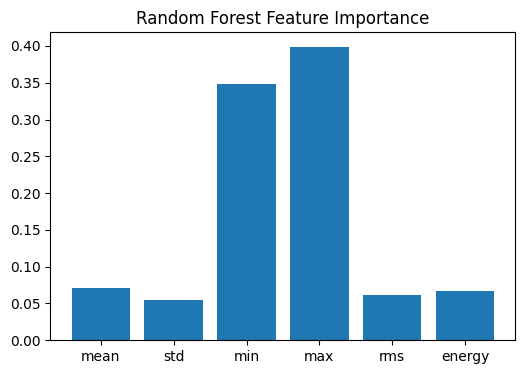

In [14]:
importances = rf_model.feature_importances_
feature_names = ['mean','std','min','max','rms','energy']
plt.figure(figsize=(6,4))
plt.bar(feature_names, importances)
plt.title("Random Forest Feature Importance")
plt.show()


## Saving the models

In [20]:
import os
import joblib

BASE_MODEL_DIR = "/content/drive/MyDrive/Processed"
LSTM_SAVE_DIR = os.path.join(BASE_MODEL_DIR, "LSTM")
RF_SAVE_DIR   = os.path.join(BASE_MODEL_DIR, "RandomForest")

os.makedirs(LSTM_SAVE_DIR, exist_ok=True)
os.makedirs(RF_SAVE_DIR, exist_ok=True)

# ---------- Save LSTM Model ----------
lstm_model.save(
    os.path.join(LSTM_SAVE_DIR, "lstm_ecg_model.keras")
)
joblib.dump(
    le,
    os.path.join(LSTM_SAVE_DIR, "label_encoder.pkl")
)
lstm_metadata = {
    "input_shape": input_shape,      # (beat_length, 1)
    "num_classes": num_classes,
    "class_names": classes
}
joblib.dump(
    lstm_metadata,
    os.path.join(LSTM_SAVE_DIR, "metadata.pkl")
)

# ---------- Save Random Forest Model ----------
joblib.dump(
    rf_model,
    os.path.join(RF_SAVE_DIR, "rf_ecg_model.pkl")
)

rf_metadata = {
    "feature_names": feature_names,
    "num_features": len(feature_names),
    "class_names": classes
}
joblib.dump(
    rf_metadata,
    os.path.join(RF_SAVE_DIR, "metadata.pkl")
)

# Save the same LabelEncoder for RF
joblib.dump(
    le,
    os.path.join(RF_SAVE_DIR, "label_encoder.pkl")
)

print("LSTM and Random Forest models saved successfully.")


LSTM and Random Forest models saved successfully.
